<a href="https://colab.research.google.com/github/Ajo-Antony/Antony-sebastian-Portfolio/blob/main/Butterfly_diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision

from torchvision import transforms
from datasets import load_dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

import torch.nn.functional as F
from diffusers import DDPMScheduler
from diffusers import UNet2DModel
from datasets import load_dataset
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
dataset= load_dataset("huggan/smithsonian_butterflies_subset",split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [3]:
image_size=64

preprocess=transforms.Compose([
        transforms.Resize((image_size, image_size)),  # Resize
        transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
        transforms.ToTensor(),  # Convert to tensor (0, 1)
        transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
    ])

In [4]:
dataset.set_transform(preprocess)
batch_size=64
def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

device="cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def show_images(image):
    plt.imshow(make_grid(image*0.5+0.5).permute(1,2,0))

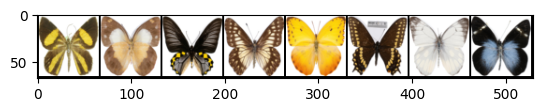

In [6]:
batch=next(iter(train_dataloader))
show_images(batch['images'][:8])

In [7]:
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.001, beta_end=0.02)
model=UNet2DModel(sample_size=64,block_out_channels=(64,128,256,512,512,512,512),
                  down_block_types=('DownBlock2D', 'AttnDownBlock2D', 'AttnDownBlock2D',\
                                    'AttnDownBlock2D','AttnDownBlock2D','AttnDownBlock2D',\
                                    'AttnDownBlock2D'),
                   up_block_types=('AttnUpBlock2D','AttnUpBlock2D','AttnUpBlock2D',\
                                   'AttnUpBlock2D', 'AttnUpBlock2D', 'AttnUpBlock2D',\
                                   'UpBlock2D'))

In [ ]:
num_epochs=30
ls=1e-4
model=model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=ls)
losses = []

for epoch in range(num_epochs):
    for step, batch in enumerate(train_dataloader):

        clean_images = batch["images"].to(device)

        noise = torch.randn(clean_images.shape).to(clean_images.device)
        timesteps = torch.randint(
            0,
            scheduler.num_train_timesteps,
            (clean_images.shape[0],),
            device=clean_images.device,
        ).long()

        noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        loss = F.mse_loss(noise_pred, noise)

        losses.append(loss.item())
        loss.backward(loss)
        optimizer.step()
        optimizer.zero_grad()
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1} Loss {loss}")

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:173: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


In [ ]:
plt.figure(figsize=(10,3))
plt.plot(losses)

In [ ]:
from diffusers import DDPMPipeline

pipe= DDPMPipeline(unet=model,scheduler=scheduler)
pipe.to(device)

In [ ]:
DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.17.1",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [ ]:
pipe().images[0]


In [ ]:
pipe().images[0]